# Visualisation Des Donnees AQUA-ATMOS

Ce notebook sert a explorer les donnees climatiques ouvertes et les donnees synthetiques qui serviront a l'entrainement.


## 1. Chargement

**Objectif**
Charger les donnees synthetiques annuelles et les historiques climatiques normalises.

**Resultat attendu**
Obtenir deux DataFrames propres, avec les types numeriques corrects et une liste claire des villes disponibles.


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SYNTHETIC_PATH = PROJECT_ROOT / "data" / "synthetic" / "synthetic_year.csv"
CLIMATE_DIR = PROJECT_ROOT / "data" / "climate" / "normalized"


def load_climate_history(climate_dir: Path) -> pd.DataFrame:
    frames = []
    for csv_path in sorted(climate_dir.glob("*_hourly.csv")):
        frame = pd.read_csv(csv_path)
        frame["timestamp_utc"] = pd.to_datetime(frame["timestamp_utc"])
        numeric_columns = [
            "year",
            "month",
            "day",
            "hour",
            "temp_air_c",
            "hr_pct",
            "dew_point_c",
            "solar_wm2",
            "cloud_cover_pct",
        ]
        frame[numeric_columns] = frame[numeric_columns].apply(pd.to_numeric)
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)


synthetic_df = pd.read_csv(SYNTHETIC_PATH)
climate_df = load_climate_history(CLIMATE_DIR)

synthetic_df.head(), climate_df.head(), sorted(climate_df["city_id"].unique().tolist())


(    profile_name  day_index  hour  temp_air_c  hr_pct  solar_wm2  pv_voltage  \
 0  dakar_coastal          0     0       18.42   67.72        0.0         0.0   
 1  dakar_coastal          0     1       17.25   71.46        0.0         0.0   
 2  dakar_coastal          0     2       16.33   71.10        0.0         0.0   
 3  dakar_coastal          0     3       16.70   73.81        0.0         0.0   
 4  dakar_coastal          0     4       16.96   72.79        0.0         0.0   
 
    temp_collector_c  temp_cond_c  delta_hr_sorbent  reservoir_level_pct  \
 0             18.26        13.90              2.39            11.125484   
 1             16.69        13.80              2.72            12.518850   
 2             17.25        12.65              1.31            13.717395   
 3             16.78        14.22              1.12            14.905522   
 4             17.37        13.16              0.11            16.098170   
 
    soc_battery_pct  dew_point_c  humidity_ratio_gkg  

## 2. Vue D'Ensemble

**Objectif**
Verifier la taille, les colonnes et les statistiques descriptives principales.

**Resultat attendu**
Confirmer que les deux jeux de donnees sont exploitables avant de passer aux graphiques.


In [4]:
print("Synthetic shape:", synthetic_df.shape)
print("Climate shape:", climate_df.shape)

display(synthetic_df.describe(include="all").T)
display(climate_df.describe(include="all").T)


Synthetic shape: (8760, 19)
Climate shape: (315648, 12)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
profile_name,8760,1,dakar_coastal,8760,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_index,8760.0,NaN,NaN,NaN,182.0,105.372043,0.0,91.0,182.0,273.0,364.0
hour,8760.0,NaN,NaN,NaN,11.5,6.922582,0.0,5.75,11.5,17.25,23.0
temp_air_c,8760.0,NaN,NaN,NaN,25.640951,4.540016,15.69,22.19,25.63,29.11,35.46
hr_pct,8760.0,NaN,NaN,NaN,67.679725,12.779055,35.12,58.6,67.38,77.77,96.67
solar_wm2,8760.0,NaN,NaN,NaN,171.913967,215.78312,0.0,0.0,0.0,353.075,706.24
pv_voltage,8760.0,NaN,NaN,NaN,5.459526,5.833866,0.0,0.0,2.75,11.0625,16.63
temp_collector_c,8760.0,NaN,NaN,NaN,30.867051,9.650529,15.1,22.74,28.32,40.24,51.76
temp_cond_c,8760.0,NaN,NaN,NaN,22.916796,4.389735,11.93,19.6675,22.84,26.17,33.08
delta_hr_sorbent,8760.0,NaN,NaN,NaN,1.170271,1.44109,0.0,0.0,0.53,2.07,6.27


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
city_id,315648,6,abidjan,52608,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp_utc,315648,NaN,NaN,NaN,2021-12-31 23:30:00,2019-01-01 00:00:00,2020-07-01 23:45:00,2021-12-31 23:30:00,2023-07-02 23:15:00,2024-12-31 23:00:00,NaN
year,315648.0,NaN,NaN,NaN,2021.500456,2019.0,2020.0,2021.5,2023.0,2024.0,1.708184
month,315648.0,NaN,NaN,NaN,6.521898,1.0,4.0,7.0,10.0,12.0,3.448992
day,315648.0,NaN,NaN,NaN,15.732664,1.0,8.0,16.0,23.0,31.0,8.801384
hour,315648.0,NaN,NaN,NaN,11.5,0.0,5.75,11.5,17.25,23.0,6.922198
temp_air_c,315648.0,NaN,NaN,NaN,23.709694,4.1,21.3,24.6,26.8,48.0,4.704529
hr_pct,315648.0,NaN,NaN,NaN,76.1742,3.0,68.0,81.0,90.0,100.0,19.096621
dew_point_c,315648.0,NaN,NaN,NaN,18.569589,-20.3,14.3,21.7,23.6,27.0,6.582298
solar_wm2,315648.0,NaN,NaN,NaN,224.872491,0.0,0.0,10.0,452.0,1123.0,300.487304


## 3. Couverture Par Ville

**Objectif**
Mesurer la couverture temporelle et le volume de donnees pour chaque ville.

**Resultat attendu**
Verifier qu'aucune ville n'est sous-representee avant l'entrainement.


In [5]:
coverage = (
    climate_df.groupby("city_id")
    .agg(
        rows=("timestamp_utc", "size"),
        start=("timestamp_utc", "min"),
        end=("timestamp_utc", "max"),
        min_temp=("temp_air_c", "min"),
        max_temp=("temp_air_c", "max"),
        min_hr=("hr_pct", "min"),
        max_hr=("hr_pct", "max"),
    )
    .sort_index()
)
display(coverage)


,rows,start,end,min_temp,max_temp,min_hr,max_hr
city_id,,,,,,,
abidjan,52608,2019-01-01,2024-12-31 23:00:00,17.0,34.4,22.0,100.0
agadir,52608,2019-01-01,2024-12-31 23:00:00,8.6,48.0,4.0,100.0
dakar,52608,2019-01-01,2024-12-31 23:00:00,16.6,38.5,7.0,100.0
douala,52608,2019-01-01,2024-12-31 23:00:00,21.0,36.7,33.0,100.0
mombasa,52608,2019-01-01,2024-12-31 23:00:00,21.0,33.0,41.0,100.0
walvis_bay,52608,2019-01-01,2024-12-31 23:00:00,4.1,40.8,3.0,100.0


## 4. Distributions Climatiques

**Objectif**
Comparer les distributions de temperature, humidite relative et rayonnement solaire entre les villes.

**Resultat attendu**
Voir si le panel retenu couvre bien des regimes climatiques differents.


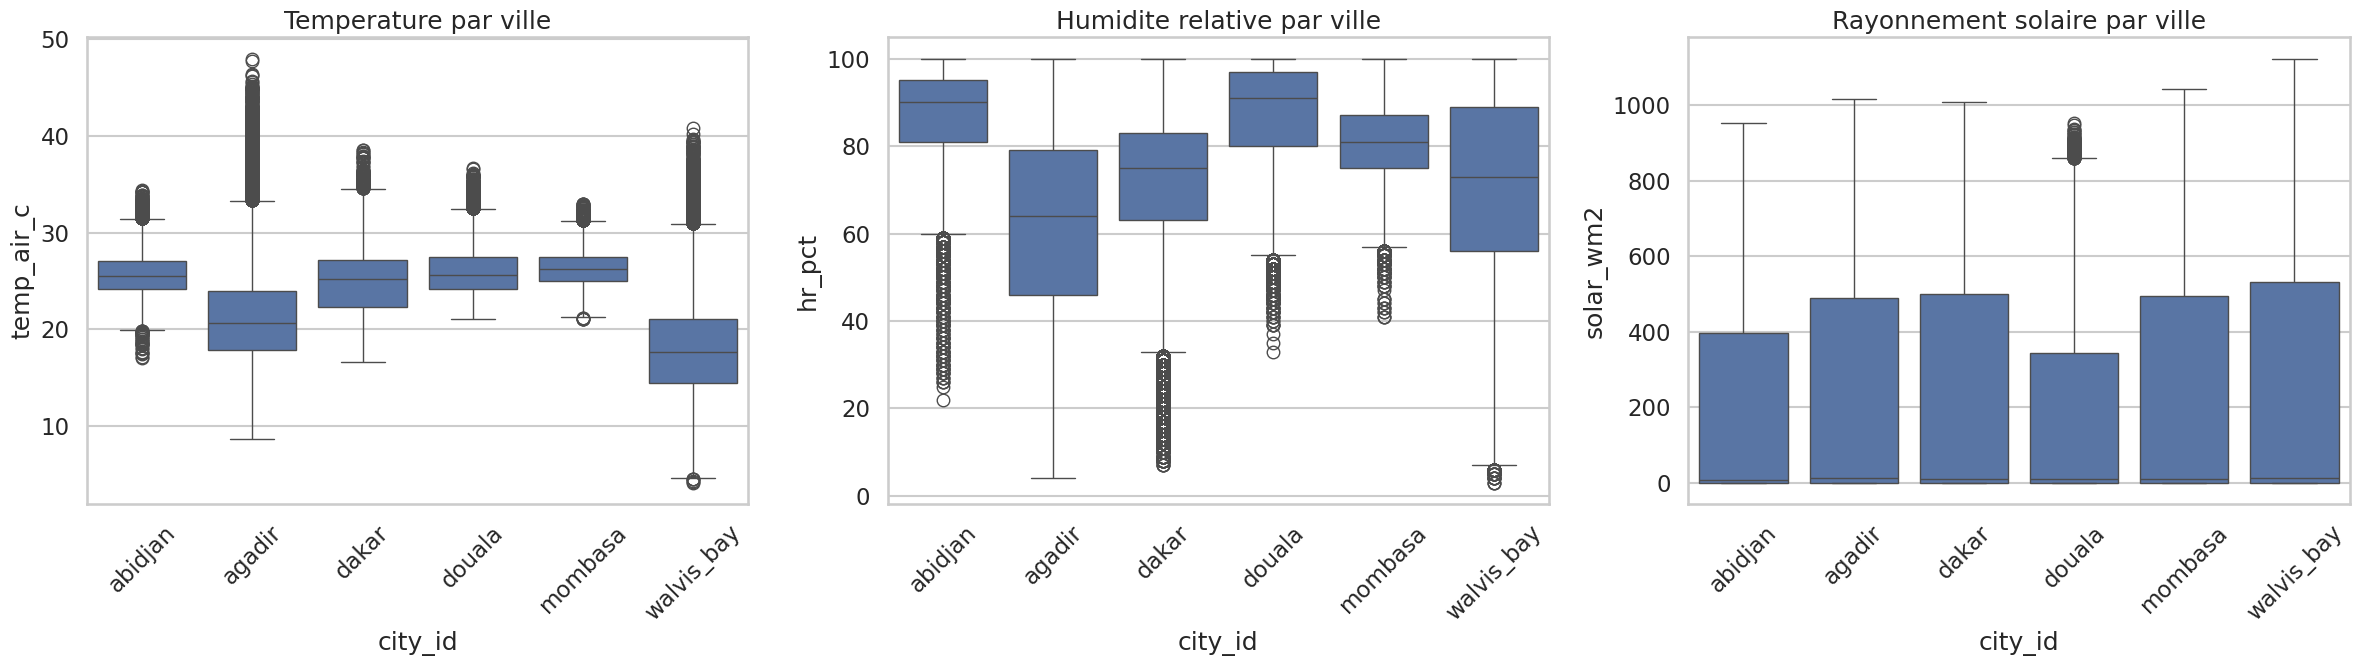

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

sns.boxplot(data=climate_df, x="city_id", y="temp_air_c", ax=axes[0])
axes[0].set_title("Temperature par ville")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=climate_df, x="city_id", y="hr_pct", ax=axes[1])
axes[1].set_title("Humidite relative par ville")
axes[1].tick_params(axis="x", rotation=45)

sns.boxplot(data=climate_df, x="city_id", y="solar_wm2", ax=axes[2])
axes[2].set_title("Rayonnement solaire par ville")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 5. Profils Horaires Moyens

**Objectif**
Visualiser le cycle journalier moyen de la temperature, de l'humidite et du solaire pour chaque ville.

**Resultat attendu**
Verifier que les donnees reelles restituent des profils jour/nuit coherents.


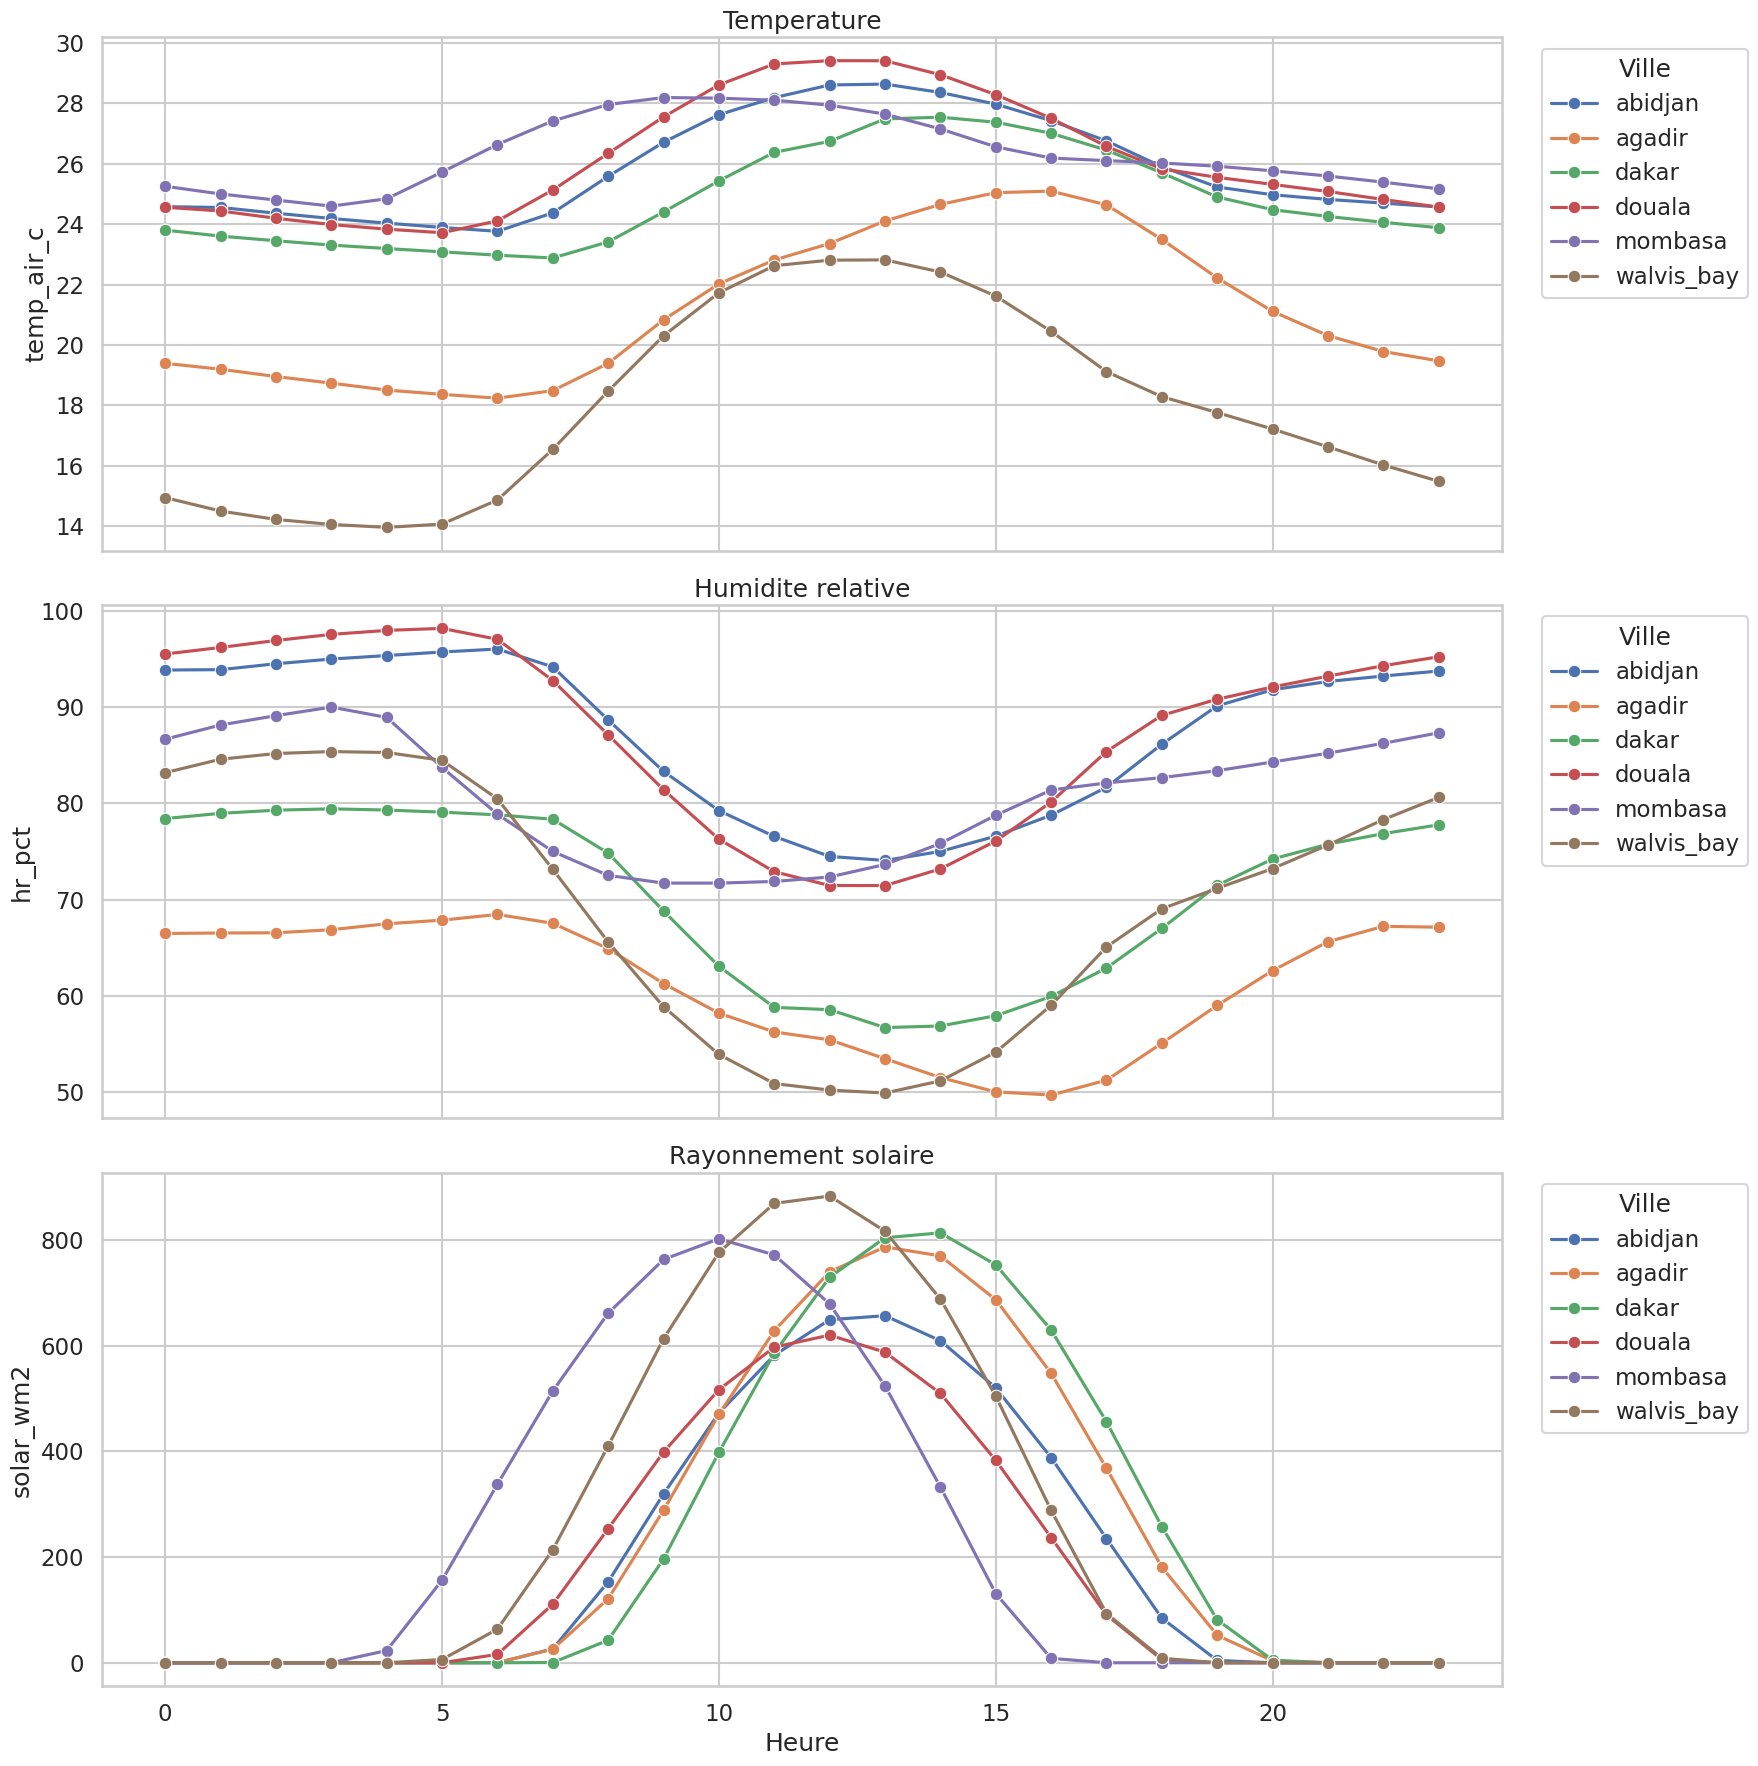

In [7]:
hourly_profile = (
    climate_df.groupby(["city_id", "hour"])
    .agg(
        temp_air_c=("temp_air_c", "mean"),
        hr_pct=("hr_pct", "mean"),
        solar_wm2=("solar_wm2", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(3, 1, figsize=(18, 18), sharex=True)
metrics = ["temp_air_c", "hr_pct", "solar_wm2"]
titles = ["Temperature", "Humidite relative", "Rayonnement solaire"]

for ax, metric, title in zip(axes, metrics, titles):
    sns.lineplot(data=hourly_profile, x="hour", y=metric, hue="city_id", marker="o", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Heure")
    ax.legend(title="Ville", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


## 6. Saisonnalite

**Objectif**
Etudier les variations mensuelles par ville.

**Resultat attendu**
Identifier les mois favorables et defavorables a la production potentielle.


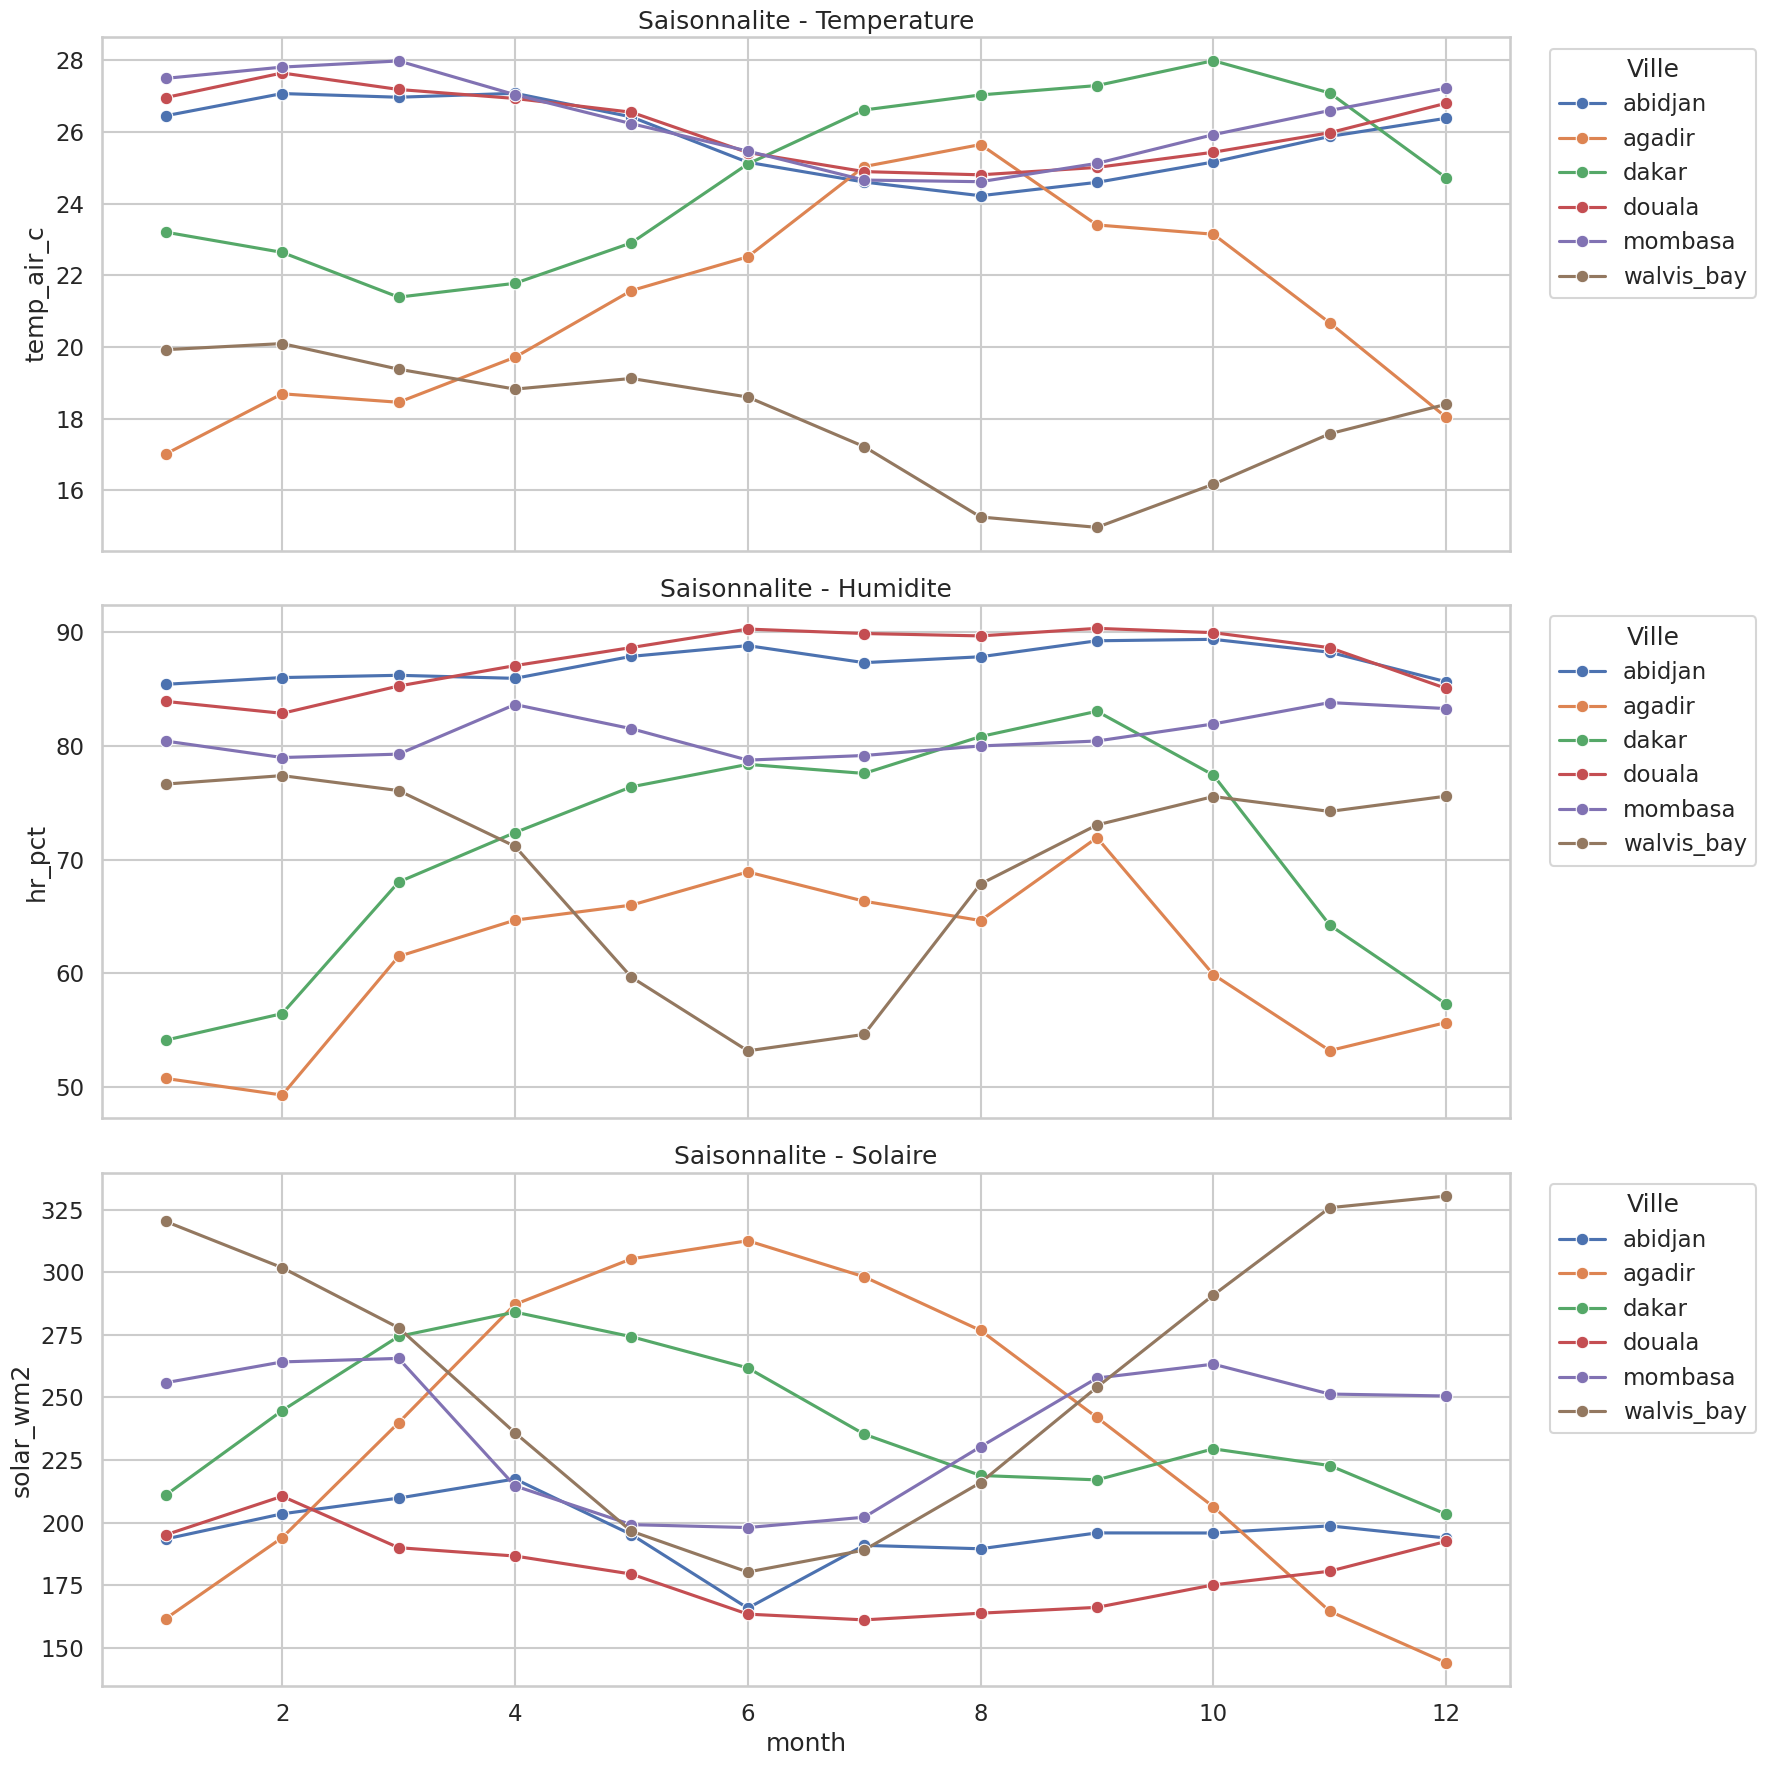

In [8]:
monthly_profile = (
    climate_df.groupby(["city_id", "month"])
    .agg(
        temp_air_c=("temp_air_c", "mean"),
        hr_pct=("hr_pct", "mean"),
        solar_wm2=("solar_wm2", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(3, 1, figsize=(18, 18), sharex=True)
for ax, metric, title in zip(axes, ["temp_air_c", "hr_pct", "solar_wm2"], ["Temperature", "Humidite", "Solaire"]):
    sns.lineplot(data=monthly_profile, x="month", y=metric, hue="city_id", marker="o", ax=ax)
    ax.set_title(f"Saisonnalite - {title}")
    ax.legend(title="Ville", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


## 7. Cas Rares Et Extemes

**Objectif**
Isoler les queues de distribution qui devront etre preservees lors de l'entrainement et de l'evaluation.

**Resultat attendu**
Obtenir un tableau des seuils extremes par ville pour guider les scenarios de test.


In [9]:
extremes = (
    climate_df.groupby("city_id")
    .agg(
        temp_p01=("temp_air_c", lambda s: s.quantile(0.01)),
        temp_p99=("temp_air_c", lambda s: s.quantile(0.99)),
        hr_p01=("hr_pct", lambda s: s.quantile(0.01)),
        hr_p99=("hr_pct", lambda s: s.quantile(0.99)),
        solar_p01=("solar_wm2", lambda s: s.quantile(0.01)),
        solar_p99=("solar_wm2", lambda s: s.quantile(0.99)),
    )
    .sort_index()
)
display(extremes)


,temp_p01,temp_p99,hr_p01,hr_p99,solar_p01,solar_p99
city_id,,,,,,
abidjan,22.0,31.4,61.0,99.0,0.0,825.93
agadir,11.8,36.1,13.0,96.0,0.0,955.00
dakar,18.2,31.9,18.0,94.0,0.0,934.00
douala,22.5,32.8,55.0,100.0,0.0,808.00
mombasa,22.8,30.9,61.0,96.0,0.0,954.00
walvis_bay,7.9,32.9,11.0,100.0,0.0,1062.00


## 8. Cibles Synthetiques

**Objectif**
Observer l'equilibre des labels produits par les regles metier.

**Resultat attendu**
Identifier les eventuels desequilibres de classes avant l'entrainement.


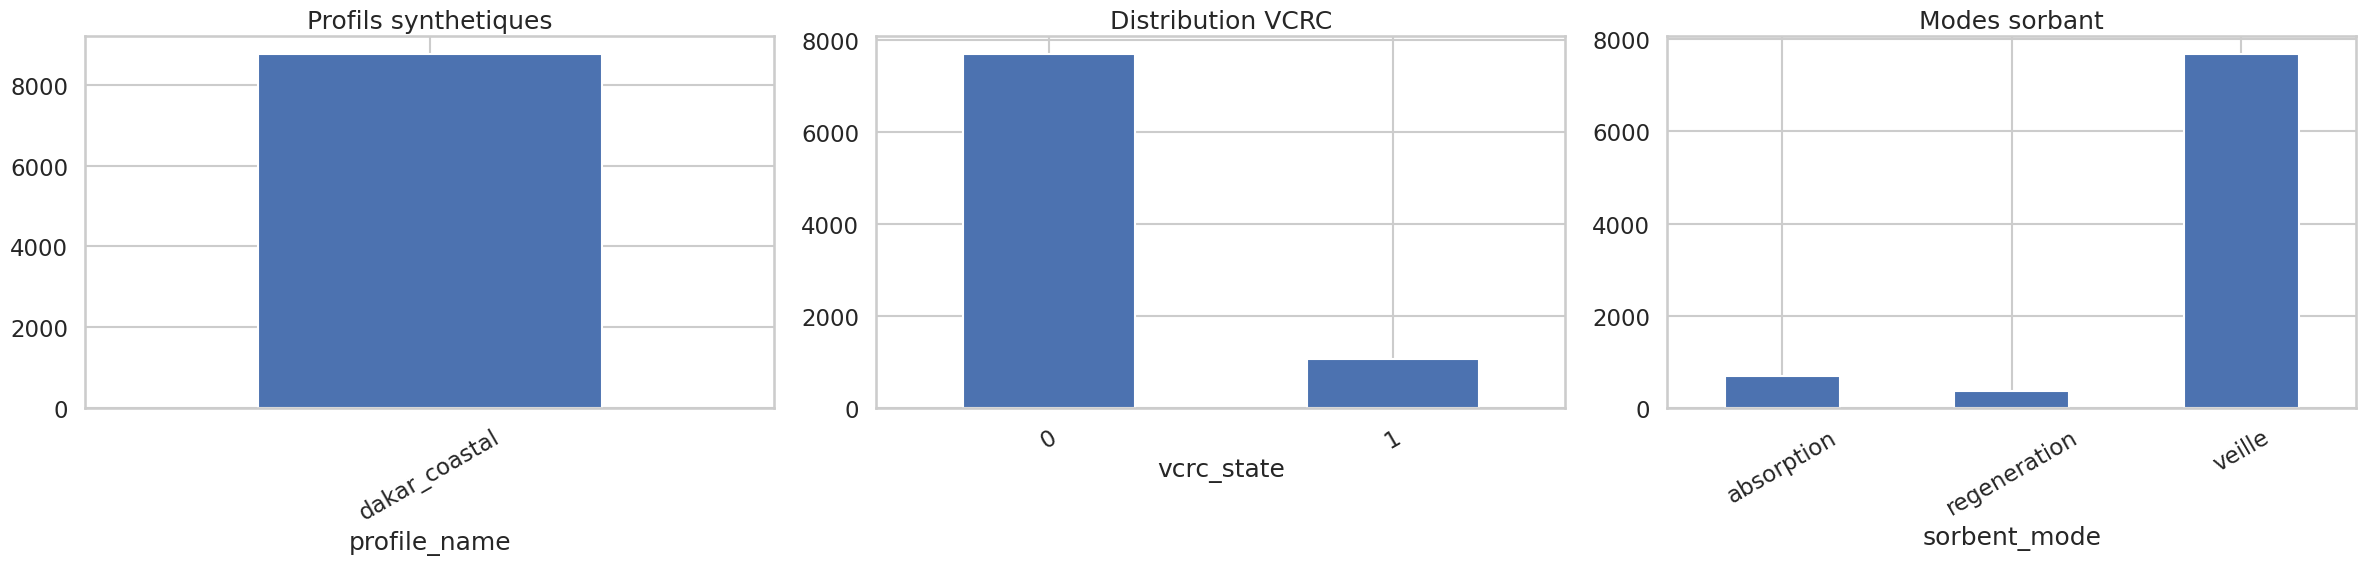

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

synthetic_df["profile_name"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Profils synthetiques")
synthetic_df["vcrc_state"].value_counts().sort_index().plot(kind="bar", ax=axes[1], title="Distribution VCRC")
synthetic_df["sorbent_mode"].value_counts().sort_index().plot(kind="bar", ax=axes[2], title="Modes sorbant")

for ax in axes:
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()
